Dataset loaded. Shape: (85089, 7)
Sampling Period: 0.8s
     u     T0     T1     T2     T3     T4    t
0  0.0  27.56  29.18  29.18  27.62  29.25  0.0
1  0.0  27.56  29.18  29.18  27.68  29.25  0.8
2  0.0  27.56  29.18  29.18  27.68  29.25  1.6
3  0.0  27.56  29.18  29.18  27.68  29.25  2.4
4  0.0  27.56  29.18  29.18  27.68  29.25  3.2


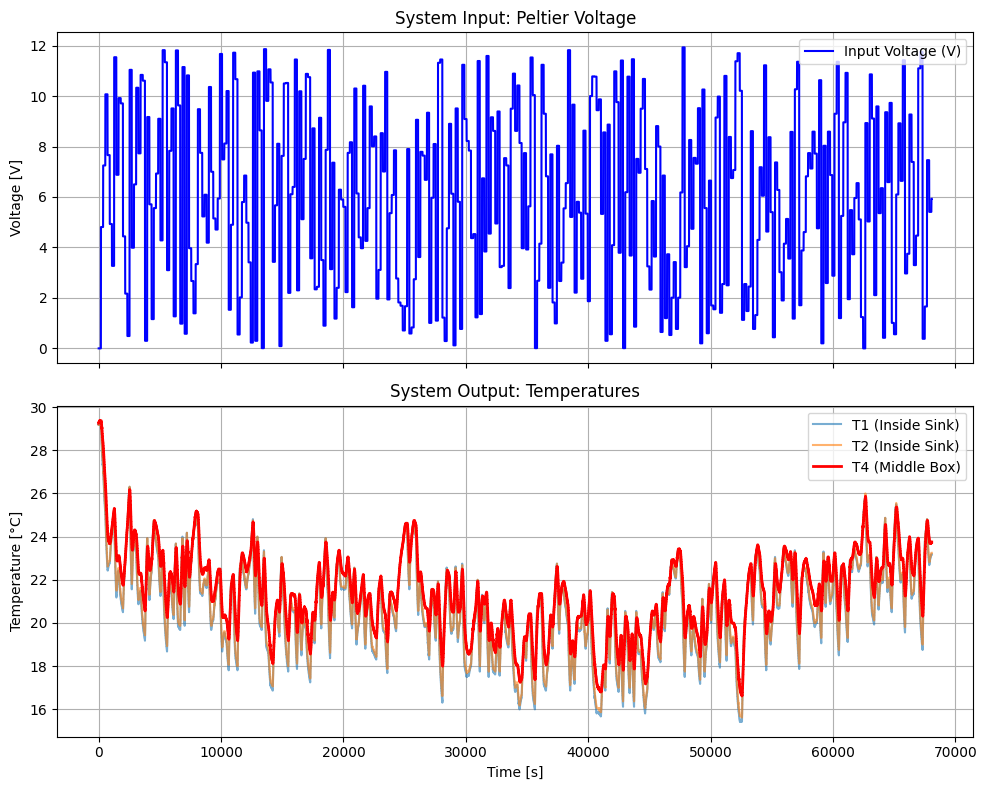

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the dataset
try:
    df = pd.read_csv('data.csv', header=None)
except FileNotFoundError:
    print("Error: 'data.csv' file not found.")
    exit(1)

# 2. Assign column names based on system description
# Col 0 = Input, Col 1..5 = Temperatures T0..T4
df.columns = ['u', 'T0', 'T1', 'T2', 'T3', 'T4']

# 3. Create Time Vector
Ts = 0.8 # Sampling period in seconds
df['t'] = df.index * Ts

# 4. Overview of the data
print(f"Dataset loaded. Shape: {df.shape}")
print(f"Sampling Period: {Ts}s")
print(df.head())

# 5. Visualization
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Plot Input Voltage
ax[0].plot(df['t'], df['u'], color='blue', label='Input Voltage (V)')
ax[0].set_ylabel('Voltage [V]')
ax[0].set_title('System Input: Peltier Voltage')
ax[0].grid(True)
ax[0].legend()

# Plot Temperatures
# Focusing on T4 (center) and T1/T2 (inside sinks) as they represent the internal dynamics
ax[1].plot(df['t'], df['T1'], label='T1 (Inside Sink)', alpha=0.6)
ax[1].plot(df['t'], df['T2'], label='T2 (Inside Sink)', alpha=0.6)
ax[1].plot(df['t'], df['T4'], label='T4 (Middle Box)', color='red', linewidth=2)
ax[1].set_ylabel('Temperature [°C]')
ax[1].set_xlabel('Time [s]')
ax[1].set_title('System Output: Temperatures')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

--- Analysis Results ---
Estimated Dominant Time Constant (tau): 1147.20 s
Calculated Target Sampling Time (tau/4): 286.80 s
Original Sampling Time: 0.8 s
Selected Decimation Factor: 358
New Equivalent Sampling Time: 286.40 s
New Dataset Shape: (238, 7)


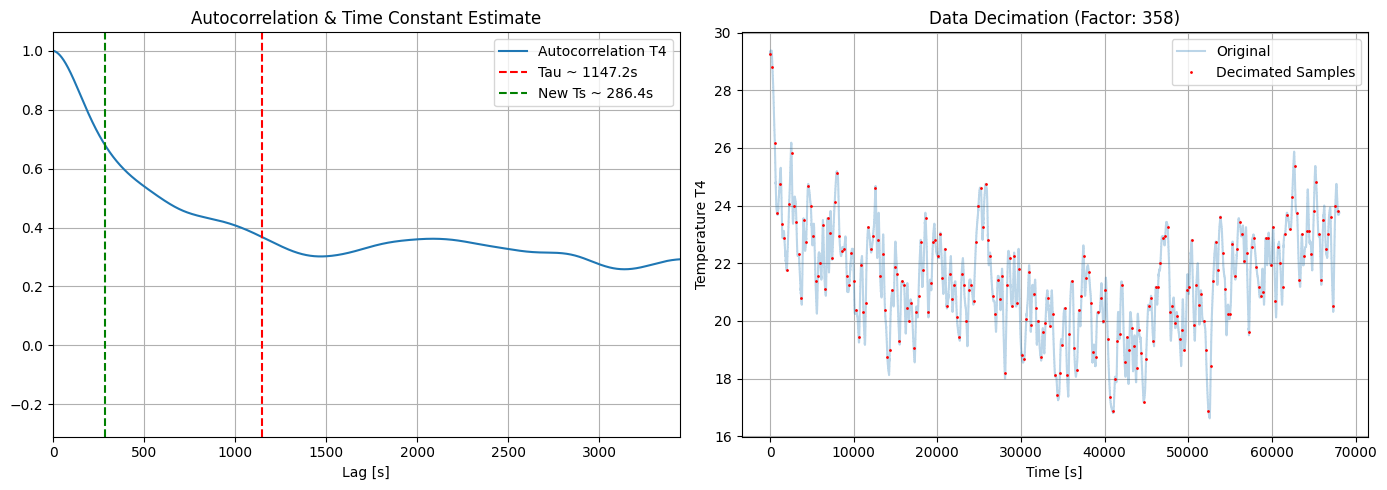

In [2]:
from scipy import signal

# --- 1. Data Analysis ---

# A. Autocorrelation Analysis to estimate Time Constant (tau)
# We look for the lag where autocorrelation drops to 1/e (~0.368)
y_centered = (df['T4'] - df['T4'].mean()).to_numpy()
# Compute autocorrelation
acf = np.correlate(y_centered, y_centered, mode='full')
acf = acf[len(acf)//2:] # Keep only positive lags
acf = acf / acf[0] # Normalize

# Find the lag (index) where ACF drops below 1/e
lags = np.arange(len(acf)) * Ts
try:
    tau_index = np.where(acf < np.exp(-1))[0][0]
    estimated_tau = lags[tau_index]
except IndexError:
    estimated_tau = lags[-1] # Fallback if signal is very slow

# B. Frequency Domain Analysis (PSD)
f, Pxx = signal.welch(y_centered, fs=1/Ts, nperseg=1024)

# --- 2. Determine Decimation Factor ---

# Rule of thumb: We want about 4 to 10 samples within one time constant.
target_Ts = estimated_tau / 4
decimation_factor = int(np.round(target_Ts / Ts))

# Ensure decimation is at least 1
if decimation_factor < 1:
    decimation_factor = 1

new_Ts = Ts * decimation_factor

# --- 3. Apply Decimation ---
# We use simple slicing [::N] to avoid adding phase lag from digital filters,
# which can complicate delay estimation later.
df_decimated = df.iloc[::decimation_factor].copy().reset_index(drop=True)

# --- 4. Visualization & Reporting ---
print(f"--- Analysis Results ---")
print(f"Estimated Dominant Time Constant (tau): {estimated_tau:.2f} s")
print(f"Calculated Target Sampling Time (tau/4): {target_Ts:.2f} s")
print(f"Original Sampling Time: {Ts} s")
print(f"Selected Decimation Factor: {decimation_factor}")
print(f"New Equivalent Sampling Time: {new_Ts:.2f} s")
print(f"New Dataset Shape: {df_decimated.shape}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Autocorrelation
ax[0].plot(lags, acf, label='Autocorrelation T4')
ax[0].axvline(estimated_tau, color='r', linestyle='--', label=f'Tau ~ {estimated_tau:.1f}s')
ax[0].axvline(new_Ts, color='g', linestyle='--', label=f'New Ts ~ {new_Ts:.1f}s')
ax[0].set_xlim(0, estimated_tau*3)
ax[0].set_title('Autocorrelation & Time Constant Estimate')
ax[0].set_xlabel('Lag [s]')
ax[0].legend()
ax[0].grid(True)

# Plot Comparison of Raw vs Decimated
ax[1].plot(df['t'], df['T4'], label='Original', alpha=0.3)
ax[1].plot(df_decimated['t'], df_decimated['T4'], 'r.', markersize=2, label='Decimated Samples')
ax[1].set_title(f'Data Decimation (Factor: {decimation_factor})')
ax[1].set_xlabel('Time [s]')
ax[1].set_ylabel('Temperature T4')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

--- 1. Relevance Analysis ---
Average Absolute Correlation to T4: 0.4553
Correlations with T4:
u    -0.159094
T0    0.063018
T1    0.948024
T2    0.962838
T3    0.143478
Name: T4, dtype: float64

Variables exceeding average correlation threshold: ['T1', 'T2']

--- 2. Redundancy Analysis (Threshold: 0.9) ---
Selected 'T2'
Excluding 'T1': Highly correlated (0.9983) with selected 'T2'

--- Final Selection ---
Selected Inputs: ['T2']
Target: T4


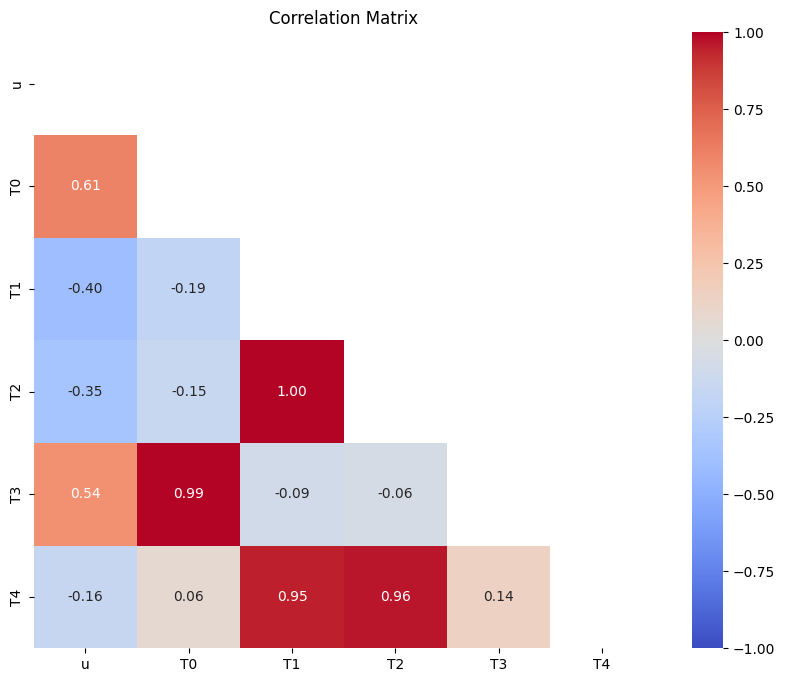

In [3]:
import seaborn as sns

# We use the decimated dataframe to avoid noise from oversampling
# The columns of interest are u, T0, T1, T2, T3 (candidates) and T4 (target)
candidates = ['u', 'T0', 'T1', 'T2', 'T3']
target = 'T4'

# 1. Compute Correlation Matrix
# We calculate correlation on the full set including target to see Input-Output and Input-Input relations
corr_matrix = df_decimated[candidates + [target]].corr()

# 2. Filter by Relevance (Correlation with Target)
# Extract correlations with T4 (excluding T4 itself)
target_corrs = corr_matrix[target].drop(target)
abs_target_corrs = target_corrs.abs()

# Calculate threshold (average of absolute correlations)
avg_corr = abs_target_corrs.mean()
relevant_vars = abs_target_corrs[abs_target_corrs > avg_corr].index.tolist()

print(f"--- 1. Relevance Analysis ---")
print(f"Average Absolute Correlation to {target}: {avg_corr:.4f}")
print("Correlations with T4:")
print(target_corrs)
print(f"\nVariables exceeding average correlation threshold: {relevant_vars}")

# 3. Filter by Redundancy (Multicollinearity Check)
# We iterate through relevant variables and remove those highly correlated with an already selected variable
# Threshold for 'high' correlation between inputs (usually 0.85 to 0.95)
redundancy_threshold = 0.90
final_inputs = []

# Sort relevant variables by their correlation strength to T4 (descending)
# This ensures we prioritize the "best" predictor when choosing between two redundant ones.
sorted_candidates = abs_target_corrs[relevant_vars].sort_values(ascending=False).index.tolist()

print(f"\n--- 2. Redundancy Analysis (Threshold: {redundancy_threshold}) ---")

for candidate in sorted_candidates:
    is_redundant = False
    for existing in final_inputs:
        # Check correlation between the current candidate and already selected inputs
        inter_corr = abs(corr_matrix.loc[candidate, existing])
        if inter_corr > redundancy_threshold: # type: ignore
            print(f"Excluding '{candidate}': Highly correlated ({inter_corr:.4f}) with selected '{existing}'")
            is_redundant = True
            break
    
    if not is_redundant:
        final_inputs.append(candidate)
        print(f"Selected '{candidate}'")

print(f"\n--- Final Selection ---")
print(f"Selected Inputs: {final_inputs}")
print(f"Target: {target}")

# 4. Visualization
plt.figure(figsize=(10, 8))
# Mask upper triangle for better readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# Update the working dataframe to contain only selected inputs + target + time
# This makes subsequent steps cleaner
selected_columns = ['t'] + final_inputs + [target]
df_modeling = df_decimated[selected_columns].copy()

Total Samples: 238
Training Set:   142 samples (59.7%)
Validation Set: 59 samples (24.8%)
Test Set:       37 samples (15.5%)


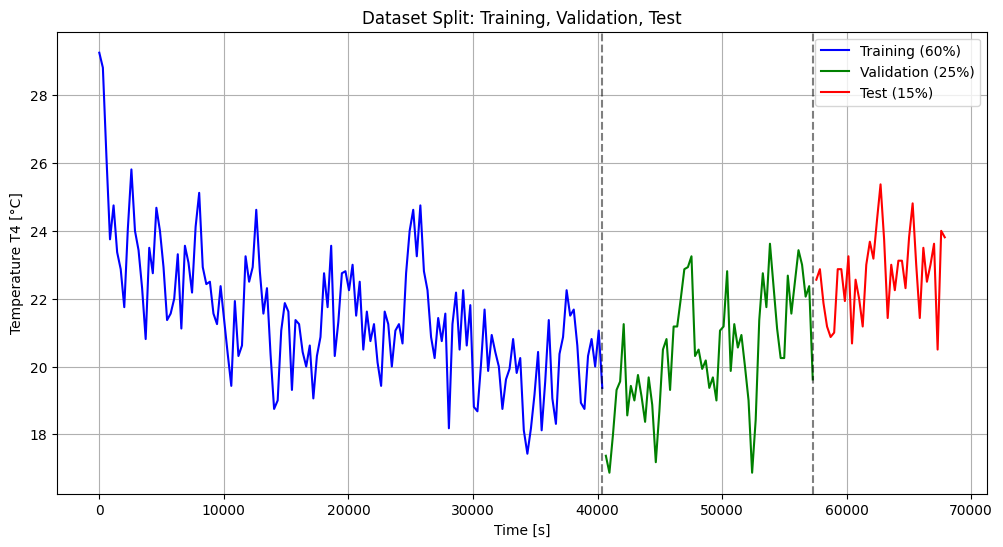

In [4]:
# Calculate split indices based on the fraction of total samples
N = len(df_decimated)
n_train = int(N * 0.60)
n_val = int(N * 0.25)
n_test = N - n_train - n_val  # Remaining 15%

# Perform the Sequential Split
# We use .copy() to ensure these are distinct dataframes, not views
train_df = df_decimated.iloc[:n_train].copy()
val_df = df_decimated.iloc[n_train:n_train+n_val].copy()
test_df = df_decimated.iloc[n_train+n_val:].copy()

# Verify the splits
print(f"Total Samples: {N}")
print(f"Training Set:   {len(train_df)} samples ({len(train_df)/N:.1%})")
print(f"Validation Set: {len(val_df)} samples ({len(val_df)/N:.1%})")
print(f"Test Set:       {len(test_df)} samples ({len(test_df)/N:.1%})")

# Visualization of the Split
plt.figure(figsize=(12, 6))

# We plot the Target (T4) to show the coverage
plt.plot(train_df['t'], train_df['T4'], label='Training (60%)', color='blue')
plt.plot(val_df['t'], val_df['T4'], label='Validation (25%)', color='green')
plt.plot(test_df['t'], test_df['T4'], label='Test (15%)', color='red')

# Add vertical lines to mark boundaries
plt.axvline(train_df['t'].iloc[-1], color='k', linestyle='--', alpha=0.5)
plt.axvline(val_df['t'].iloc[-1], color='k', linestyle='--', alpha=0.5)

plt.title('Dataset Split: Training, Validation, Test')
plt.xlabel('Time [s]')
plt.ylabel('Temperature T4 [°C]')
plt.legend()
plt.grid(True)
plt.show()

--- 1. Linear ARX Structure Selection ---
Best ARX Order (na, nb): (1, 1) with AIC: 12.48

--- 2. Linear ARMAX Structure Selection ---
Best ARMAX Order (p, q): (1, 1) with AIC: 45.28

--- 3. Nonlinear Polynomial Structure (ERR) ---
Selecting top terms via Error Reduction Rate (ERR):
 Step 1: Added 'y(k-1)'
 Step 2: Added 'u(k-1)*u(k-1)'
 Step 3: Added 'y(k-2)'

--- 4. Fuzzy TS Structure Selection ---
Fuzzy Partition Coefficients (FPC) for c=[2, 3, 4, 5, 6, 7]:
[0.843, 0.765, 0.752, 0.707, 0.707, 0.656]
Best Number of Clusters (Rules): 2 (Highest FPC)


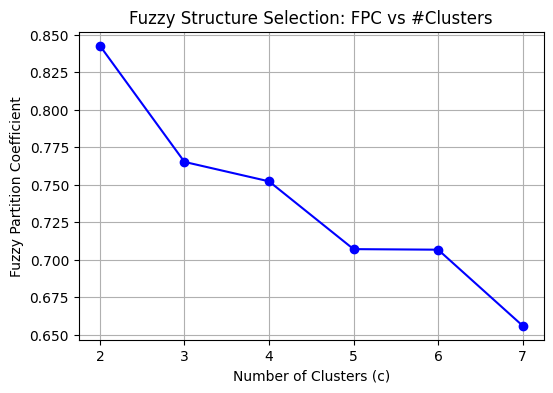

In [5]:
import itertools
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA
import skfuzzy as fuzz
from skfuzzy.cluster import cmeans

import warnings

warnings.filterwarnings("ignore", category=UserWarning)

# --- Configuration ---
# We use the test_df for structure determination
df_struct = test_df.reset_index(drop=True)
y_s = df_struct['T4'].to_numpy()
u_s = df_struct['T2'].to_numpy()
N_s = len(y_s)

# Max lags to test
max_lag = 6

# --- 1. Linear ARX Structure Selection (AIC) ---
print("--- 1. Linear ARX Structure Selection ---")
best_aic_arx = np.inf
best_order_arx = None

# Grid search for ARX(na, nb) - assuming nk=1 (min delay)
for na in range(1, max_lag + 1):
    for nb in range(1, max_lag + 1):
        # Construct regressors
        # y(k) = -a1*y(k-1)... + b1*u(k-1)...
        # We lose max(na, nb) samples
        start_idx = max(na, nb)
        y_target = y_s[start_idx:]
        
        # Build phi matrix
        cols = []
        for i in range(1, na + 1): cols.append(y_s[start_idx-i : -i]) # y terms
        for i in range(1, nb + 1): cols.append(u_s[start_idx-i : -i]) # u terms
        
        X_mat = np.column_stack(cols)
        
        # Fit OLS
        model = LinearRegression().fit(X_mat, y_target)
        rss = np.sum((y_target - model.predict(X_mat))**2)
        n_params = na + nb
        n_samples = len(y_target)
        
        # Calculate AIC: N * ln(RSS/N) + 2*k
        aic = n_samples * np.log(rss/n_samples) + 2 * n_params
        
        if aic < best_aic_arx:
            best_aic_arx = aic
            best_order_arx = (na, nb)

print(f"Best ARX Order (na, nb): {best_order_arx} with AIC: {best_aic_arx:.2f}")


# --- 2. Linear ARMAX Structure Selection (AIC) ---
print("\n--- 2. Linear ARMAX Structure Selection ---")
# ARMAX is effectively ARIMA(p, 0, q) with exogenous input
best_aic_armax = np.inf
best_order_armax = None

# Grid search (p=AR, q=MA). limiting range to save computation time
for p in range(1, 3):
    for q in range(1, 3):
        try:
            # We treat 'u' as exog. 
            # Note: ARIMA tends to be computationally heavy.
            model = ARIMA(y_s, order=(p, 0, q), exog=u_s)
            res = model.fit(method_kwargs={'warn_convergence': False})
            
            if res.aic < best_aic_armax:
                best_aic_armax = res.aic
                best_order_armax = (p, q)
        except:
            continue

print(f"Best ARMAX Order (p, q): {best_order_armax} with AIC: {best_aic_armax:.2f}")


# --- 3. Nonlinear Polynomial Structure (ERR) ---
print("\n--- 3. Nonlinear Polynomial Structure (ERR) ---")
# Simplified Forward Regression with Orthogonal Least Squares (OLS)
# We consider a candidate pool of degree 2 polynomial terms from lags 1..2

# Generate candidate regressors (y_k-1, y_k-2, u_k-1, u_k-2)
lag_poly = 2
start_idx = lag_poly
y_t = y_s[start_idx:]
candidates = {}
names = []

# Base terms
for i in range(1, lag_poly+1):
    candidates[f'y(k-{i})'] = y_s[start_idx-i : -i]
    names.append(f'y(k-{i})')
    candidates[f'u(k-{i})'] = u_s[start_idx-i : -i]
    names.append(f'u(k-{i})')

# Cross terms (Degree 2)
base_names = names.copy()
for i in range(len(base_names)):
    for j in range(i, len(base_names)):
        key = f"{base_names[i]}*{base_names[j]}"
        candidates[key] = candidates[base_names[i]] * candidates[base_names[j]]
        names.append(key)

# ERR Algorithm (Simplified)
selected_terms = []
selected_indices = []
residual = y_t.copy()
total_variance = np.sum(y_t**2)

print("Selecting top terms via Error Reduction Rate (ERR):")
for step in range(3): # Select top 3 terms
    best_err = -1
    best_term = None
    
    for name in names:
        if name in selected_terms: continue
        
        # Regressor
        col = candidates[name]
        
        # Standard ERR calculation with orthogonalization
        # Project col onto residual space
        num = np.sum(residual * col)
        den = np.sum(col**2)
        
        if den != 0:
            # Contribution to variance explained
            err_contribution = (num**2) / den
            corr = err_contribution / total_variance
        else:
            corr = 0
        
        if corr > best_err:
            best_err = corr
            best_term = name
            
    if best_term:
        selected_terms.append(best_term)
        # Update residual by projecting out the selected term
        x_sel = candidates[best_term].reshape(-1, 1)
        coeffs = np.linalg.lstsq(x_sel, residual, rcond=None)[0]
        residual = residual - (x_sel @ coeffs).flatten()
        
        # Calculate approximate ERR for this step
        err_val = 1 - (np.sum(residual**2) / total_variance)
        print(f" Step {step+1}: Added '{best_term}'")

# --- 4. Fuzzy TS Structure (Clustering Coefficient) ---
print("\n--- 4. Fuzzy TS Structure Selection ---")
# We use Fuzzy C-Means on the input-output product space [y(k-1), u(k-1)]
# to determine the number of rules (clusters).

# Construct data Z = [y(k-1), u(k-1)].T for clustering
Z = np.vstack((y_s[:-1], u_s[:-1])) 

best_fpc = -1
best_c = 2
fpcs = []

# Test cluster counts from 2 to 7
c_range = range(2, 8)
for c in c_range:
    # cntr: centers, u_mem: membership, u0: initial, d: distance, jm: obj fun, p: iter, fpc: partition coeff
    cntr, u_mem, u0, d, jm, p, fpc = cmeans(Z, c, m=2, error=0.005, maxiter=1000, init=None)
    fpcs.append(fpc)
    if fpc > best_fpc:
        best_fpc = fpc
        best_c = c

print(f"Fuzzy Partition Coefficients (FPC) for c={list(c_range)}:")
print([float(round(x, 3)) for x in fpcs])
print(f"Best Number of Clusters (Rules): {best_c} (Highest FPC)")

# Visualization of FPC
plt.figure(figsize=(6, 4))
plt.plot(c_range, fpcs, 'bo-')
plt.title('Fuzzy Structure Selection: FPC vs #Clusters')
plt.xlabel('Number of Clusters (c)')
plt.ylabel('Fuzzy Partition Coefficient')
plt.grid(True)
plt.show()